# Cycle phase & follicular→luteal transition

**Goal:** reconstruct the full cycle phases and, above all, locate the **follicular→luteal transition (ovulation)** — using only the ground truth we actually have: **period timing**.

The labels are period-anchored:
- `is_period` marks known menses; those same days are `Early follicular` in `cycle_phase`.
- `Early follicular` and `Late luteal` are the confident reproductive-phase anchors.
- `Not logged` → the **unlabeled middle** of each cycle (mid-follicular → fertile → early luteal). The transition lives here.
- `garmin_predicted_fertile` → Garmin's guess, **not** used as truth.

The plan (built step by step):
0. **Confirm the signal exists** — align every cycle by cycle-day and look for a follicular→luteal step in RHR / respiration / HRV. *(this notebook, for now)*
1. Binary anchor classifier: follicular anchors (including period days) vs `Late luteal`.
2. Score `P(luteal)` across the full calendar, including `Not logged` days.
3. Locate the per-cycle transition (crossing / change-point), constrained to the unlabeled middle before the next period.
4. Reconstruct full phases from `is_period` (known) + transition (estimated).

Validation without transition ground truth: the **luteal phase length is stable (~12–14 d)**, so `next period − transition` should cluster tightly across cycles.

In [74]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the repo root importable so the preprocessing stage can be reused here
# (collection -> preprocessing -> analysis are kept separate).
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "preprocessing").exists():
    REPO_ROOT = Path("/home/elsa/projects/garmin")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import importlib
import preprocessing.cycle_phases as cycle_phase_preprocessing
importlib.reload(cycle_phase_preprocessing)
from preprocessing.cycle_phases import derive_cycle_phases

# --- Load ---
DATA_FILE = Path("data/garmin_data_730days/garmin_data_730days.csv")
if not DATA_FILE.exists():
    DATA_FILE = REPO_ROOT / DATA_FILE

df = pd.read_csv(DATA_FILE, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

if "is_period" not in df.columns:
    raise ValueError(
        "This notebook expects freshly fetched data with an `is_period` boolean column. "
        "Re-download the CSV or migrate old raw data before running the model."
    )

# `cycle_phase` is a derived modelling column. Drop any stale copy before rebuilding it.
df = df.drop(columns=["cycle_phase"], errors="ignore")

# Derive the Early-follicular / Late-luteal anchor windows here, where their length is a
# tunable modelling choice. Shorten from the old fixed 7 to keep the anchors close to menses.
ANCHOR_DAYS = 6
df = derive_cycle_phases(df, anchor_days=ANCHOR_DAYS)

# Signals we expect to shift after ovulation (progesterone raises RHR / respiration).
SIGNALS = ["resting_hr", "avg_sleep_respiration", "hrv_rmssd", "avg_sleep_stress"]
CONFIDENT_PHASES = ["Early follicular", "Late luteal"]

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print(f"cycle_phase (anchor_days={ANCHOR_DAYS}):")
print(df["cycle_phase"].value_counts(dropna=False))
print("\nis_period:")
print(df["is_period"].value_counts(dropna=False))


Shape: (731, 55)
Date range: 2024-07-24 to 2026-07-24
cycle_phase (anchor_days=6):
cycle_phase
Not logged          413
Early follicular    162
Late luteal         156
Name: count, dtype: int64

is_period:
is_period
False    595
True     136
Name: count, dtype: int64


## Cycle segmentation

A cycle starts on the first day of `Period` (a `Period` day whose previous day is not `Period`). For each day we compute:
- `cycle_id` — which cycle it belongs to,
- `cycle_day` — days since that cycle's period start (forward alignment),
- `rev_day` — days *before the next* period start, negative (backward alignment — better for the luteal step, since luteal length is stable),
- `cycle_len` — full length of the cycle.

The final (incomplete) cycle has no next period, so its `rev_day` / `cycle_len` are `NaN` and it is excluded from alignment plots.

In [75]:
is_period = df["is_period"]
is_start = is_period & ~is_period.shift(1, fill_value=False)
df["cycle_id"] = is_start.cumsum()

cycle_start = df.groupby("cycle_id")["date"].min()
next_start = cycle_start.shift(-1)

df["cycle_day"] = (df["date"] - df["cycle_id"].map(cycle_start)).dt.days
df["next_period_start"] = df["cycle_id"].map(next_start)
df["rev_day"] = (df["date"] - df["next_period_start"]).dt.days
df["cycle_len"] = df["cycle_id"].map((next_start - cycle_start).dt.days)

complete = df[df["cycle_len"].notna()].copy()
n_cycles = complete["cycle_id"].nunique()
print(f"{n_cycles} complete cycles")
print("Cycle length: median %.0f (min %.0f, max %.0f)" % (
    complete.groupby("cycle_id")["cycle_len"].first().median(),
    complete["cycle_len"].min(), complete["cycle_len"].max()))

# Days each confident phase occupies, to sanity-check the anchoring.
print("\nMedian cycle_day per phase:")
print(complete.groupby("cycle_phase")["cycle_day"].median())

26 complete cycles
Cycle length: median 28 (min 23, max 32)

Median cycle_day per phase:
cycle_phase
Early follicular     2.5
Late luteal         24.0
Not logged          13.0
Name: cycle_day, dtype: float64


## Step 0 — does a follicular→luteal step exist?

If ovulation is detectable, aligned biometrics should show a **plateau → step up → plateau** shape: low in the follicular phase, higher in the luteal phase (RHR & respiration rise with progesterone; HRV typically dips). We look three ways:

1. **Forward** (days since period start) — ovulation timing varies, so the step is smeared.
2. **Backward** (days before next period) — luteal length is stable, so the step should sharpen.
3. **Per-cycle, baseline-normalized** — subtract each cycle's own early-follicular mean to remove months-long RHR drift and expose the *within-cycle* shift.

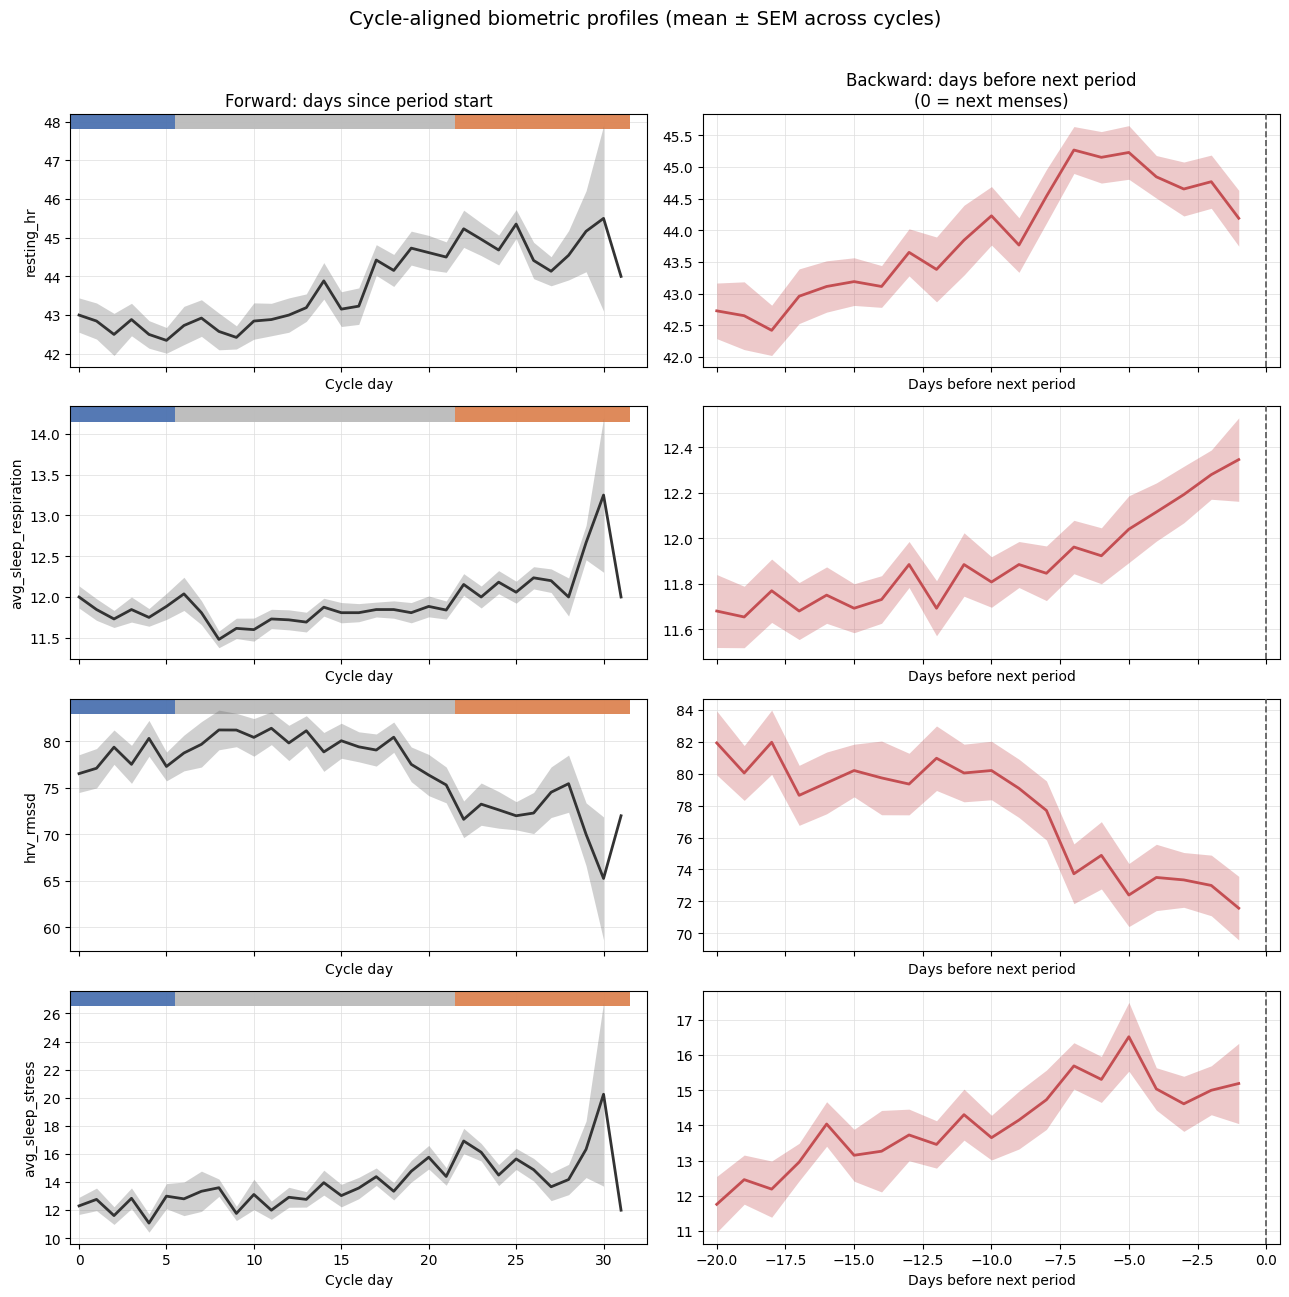

In [76]:
import matplotlib.pyplot as plt

def aligned_profile(data, x, signal):
    """
    Calculate the mean, standard error of the mean, and number of observations
    for a biometric signal grouped by an alignment column.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing the biometric data.
    x : str
        Column used for alignment, such as "cycle_day" or "rev_day".
    signal : str
        Biometric variable to summarize, such as "rhr" or "hrv".

    Returns
    -------
    mean : pandas.Series
        Mean signal value for each aligned day.
    sem : pandas.Series
        Standard error of the mean for each aligned day.
    count : pandas.Series
        Number of non-missing observations for each aligned day.
    """
    grouped = data.dropna(subset=[signal]).groupby(x)[signal]

    return grouped.mean(), grouped.sem(), grouped.count()


# Use Matplotlib's standard light style, even when the notebook uses dark mode.
plt.style.use("default")

PHASE_COLOR = {
    "Period": "#c44e52",
    "Early follicular": "#4c72b0",
    "Not logged": "#bbbbbb",
    "Late luteal": "#dd8452",
}

# squeeze=False guarantees that axes is always a two-dimensional array,
# even when SIGNALS contains only one signal.
fig, axes = plt.subplots(
    nrows=len(SIGNALS),
    ncols=2,
    figsize=(13, 3.2 * len(SIGNALS)),
    sharex="col",
    squeeze=False,
)

# Explicitly set the complete figure background to white.
fig.set_facecolor("white")

# Set the background, text, ticks, borders, and grid for every subplot.
for ax in axes.flat:
    ax.set_facecolor("white")
    ax.tick_params(
        axis="both",
        colors="black",
        labelcolor="black",
    )
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.grid(
        visible=True,
        color="#dddddd",
        linewidth=0.7,
        alpha=0.7,
    )
    # Keep grid lines behind the plotted data.
    ax.set_axisbelow(True)

# Find the most common phase for each cycle day once.
# There is no need to calculate this again for every signal.
modal_phase = (
    complete.dropna(subset=["cycle_day", "cycle_phase"])
    .groupby("cycle_day")["cycle_phase"]
    .agg(lambda values: values.mode().iloc[0])
)

for row, signal in enumerate(SIGNALS):
    # ============================================================
    # Forward alignment: days since the current period started
    # ============================================================
    ax = axes[row, 0]
    forward = complete.loc[complete["cycle_day"].between(0, 32),:]
    mean, sem, count = aligned_profile(
        data=forward,
        x="cycle_day",
        signal=signal,
    )

    ax.plot(
        mean.index,
        mean.values,
        color="#333333",
        linewidth=2,
        label="Mean",
        zorder=3,
    )

    ax.fill_between(
        mean.index,
        mean - sem,
        mean + sem,
        color="#666666",
        alpha=0.30,
        linewidth=0,
        label="Mean ± SEM",
        zorder=2,
    )

    # Add a colored strip indicating the most common phase on each cycle day.
    for cycle_day, phase in modal_phase.items():
        if 0 <= cycle_day <= 32:
            ax.axvspan(
                cycle_day - 0.5,
                cycle_day + 0.5,
                ymin=0.94,
                ymax=1.00,
                color=PHASE_COLOR.get(phase, "#cccccc"),
                alpha=0.95,
                linewidth=0,
                zorder=1,
            )

    ax.set_xlim(-0.5, 32.5)
    ax.set_ylabel(signal, color="black")
    ax.set_xlabel("Cycle day", color="black")

    if row == 0:
        ax.set_title(
            "Forward: days since period start",
            color="black",
        )


    # ============================================================
    # Backward alignment: days before the next period
    # ============================================================
    ax = axes[row, 1]
    backward = complete.loc[complete["rev_day"].between(-20, 0), :]

    mean, sem, count = aligned_profile(
        data=backward,
        x="rev_day",
        signal=signal,
    )

    ax.plot(
        mean.index,
        mean.values,
        color="#c44e52",
        linewidth=2,
        label="Mean",
        zorder=3,
    )

    ax.fill_between(
        mean.index,
        mean - sem,
        mean + sem,
        color="#c44e52",
        alpha=0.30,
        linewidth=0,
        label="Mean ± SEM",
        zorder=2,
    )

    # Day 0 marks the beginning of the next period.
    ax.axvline(
        x=0,
        color="#555555",
        linestyle="--",
        linewidth=1.2,
        zorder=4,
    )

    ax.set_xlim(-20.5, 0.5)
    ax.set_xlabel("Days before next period", color="black")

    if row == 0:
        ax.set_title(
            "Backward: days before next period\n(0 = next menses)",
            color="black",
        )


fig.suptitle(
    "Cycle-aligned biometric profiles (mean ± SEM across cycles)",
    color="black",
    fontsize=14,
    y=1.01,
)

fig.tight_layout()

plt.show()

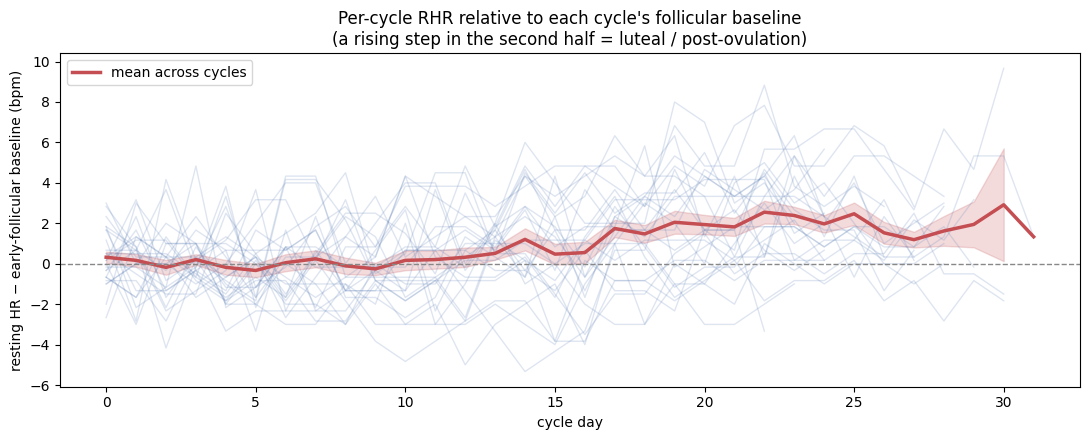

Mean RHR shift vs early-follicular baseline, by phase:
                  mean   std  count
cycle_phase                        
Early follicular  0.00  1.63    156
Late luteal       2.13  2.49    156
Not logged        0.71  2.36    404


In [77]:
# --- Per-cycle, baseline-normalized RHR (removes long-term drift) ---
signal = "resting_hr"
base = (complete[complete["is_follicular_anchor"]]
        .groupby("cycle_id")[signal].mean().rename("baseline"))
norm = complete.join(base, on="cycle_id")
norm["signal_norm"] = norm[signal] - norm["baseline"]

fig, ax = plt.subplots(figsize=(11, 4.5))

for cid, g in norm.groupby("cycle_id"):
    g = g[g["cycle_day"] <= 32].sort_values("cycle_day")
    ax.plot(g["cycle_day"], g["signal_norm"], color="#4c72b0", alpha=0.18, lw=1)
m, se, n = aligned_profile(norm[norm["cycle_day"] <= 32], "cycle_day", "signal_norm")
ax.plot(m.index, m.values, color="#c44e52", lw=2.5, label="mean across cycles")
ax.fill_between(m.index, m - se, m + se, color="#c44e52", alpha=0.2)
ax.axhline(0, color="#888", ls="--", lw=1)
ax.set_xlabel("cycle day")
ax.set_ylabel("resting HR − early-follicular baseline (bpm)")
ax.set_title("Per-cycle RHR relative to each cycle's follicular baseline\n(a rising step in the second half = luteal / post-ovulation)")
ax.legend()
fig.tight_layout()
plt.show()

print("Mean RHR shift vs early-follicular baseline, by phase:")
print(norm.groupby("cycle_phase")["signal_norm"].agg(["mean", "std", "count"]).round(2))

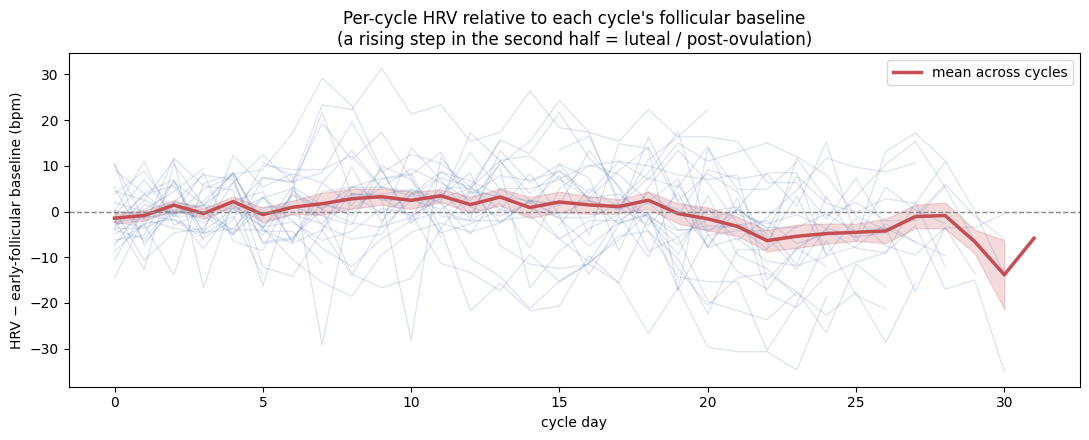

Mean HRV shift vs early-follicular baseline, by phase:
                  mean    std  count
cycle_phase                         
Early follicular -0.00   6.16    154
Late luteal      -4.96  11.24    154
Not logged        1.64   9.66    398


In [78]:
# --- Per-cycle, baseline-normalized HRV (removes long-term drift) ---
signal = "hrv_rmssd"
base = (complete[complete["is_follicular_anchor"]]
        .groupby("cycle_id")[signal].mean().rename("baseline"))
norm = complete.join(base, on="cycle_id")
norm["signal_norm"] = norm[signal] - norm["baseline"]

fig, ax = plt.subplots(figsize=(11, 4.5))

for cid, g in norm.groupby("cycle_id"):
    g = g[g["cycle_day"] <= 32].sort_values("cycle_day")
    ax.plot(g["cycle_day"], g["signal_norm"], color="#4c72b0", alpha=0.18, lw=1)
m, se, n = aligned_profile(norm[norm["cycle_day"] <= 32], "cycle_day", "signal_norm")
ax.plot(m.index, m.values, color="#c44e52", lw=2.5, label="mean across cycles")
ax.fill_between(m.index, m - se, m + se, color="#c44e52", alpha=0.2)
ax.axhline(0, color="#888", ls="--", lw=1)
ax.set_xlabel("cycle day")
ax.set_ylabel("HRV − early-follicular baseline (bpm)")
ax.set_title("Per-cycle HRV relative to each cycle's follicular baseline\n(a rising step in the second half = luteal / post-ovulation)")
ax.legend()
fig.tight_layout()
plt.show()

print("Mean HRV shift vs early-follicular baseline, by phase:")
print(norm.groupby("cycle_phase")["signal_norm"].agg(["mean", "std", "count"]).round(2))

## Step 1 — Binary anchor classifier: follicular vs luteal

Train on the **confident endpoints only** (follicular anchors, including period days, vs `Late luteal`), holding
out the `Not logged` middle (that's what Step 2 will score). Design choices from the plan:

- **Per-cycle baseline normalization** (`*_bn` features): subtract each cycle's own
  follicular-anchor mean, so the model sees the *within-cycle* shift, not months-long drift.
  Period timing is always known, so this reference is legitimately available at prediction time.
- **Features computed within each cycle** (grouped by `cycle_id`) so lags/slopes never bleed
  across cycle boundaries.
- **L1 logistic regression** to prune the many correlated lag/roll/slope/diff windows.
- **Leave-one-cycle-out CV** — every fold predicts an entirely unseen cycle.

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Signals to build features from (L1 will prune the redundant ones).
FEATURE_SIGNALS = ["resting_hr", "avg_sleep_respiration", "hrv_rmssd",
                   "avg_sleep_stress", "avgStressLevel", "sleep_score"]


def _slope(x):
    xs = np.arange(len(x))
    m = ~np.isnan(x)
    if m.sum() < 3:
        return np.nan
    return np.polyfit(xs[m], x[m], 1)[0]


def add_features(data, signals, lags=(1, 2, 3), rolls=(3, 7), slopes=(5, 7), diffs=(3, 7)):
    """Per-cycle, past-only time features + per-cycle baseline-normalized (*_bn) signals."""
    parts = []
    for _, g in data.sort_values("date").groupby("cycle_id"):
        g = g.sort_values("date")
        feats = {}
        for col in signals:
            s = g[col]
            base = g.loc[g["is_follicular_anchor"], col].mean()
            feats[f"{col}_bn"] = s - base                      # within-cycle level vs follicular
            sp = s.shift(1)                                     # past-only for rolling/slope
            for l in lags:
                feats[f"{col}_lag{l}"] = s.shift(l)
            for w in rolls:
                feats[f"{col}_roll{w}"] = sp.rolling(w, min_periods=2).mean()
            for d in diffs:
                feats[f"{col}_diff{d}"] = s.diff(d)
            for w in slopes:
                feats[f"{col}_slope{w}"] = sp.rolling(w, min_periods=3).apply(_slope, raw=True)
        parts.append(pd.concat([g, pd.DataFrame(feats, index=g.index)], axis=1))
    return pd.concat(parts).sort_values("date")


df_feat = add_features(df, FEATURE_SIGNALS)
feature_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"{len(feature_cols)} engineered features built")

# Confident training rows: overlapping follicular anchors vs late-luteal anchors.
# Follicular anchors include Period days because menses is part of the follicular phase.
anchor_mask = df_feat["is_follicular_anchor"] | df_feat["is_luteal_anchor"]
anchors = df_feat[anchor_mask].copy()
anchors["anchor_label"] = np.where(anchors["is_luteal_anchor"], 1, 0)

# Keep only cycles that contain BOTH anchor classes, so every leave-one-cycle-out fold
# has both labels (a single-class fold makes ROC AUC undefined). This drops the final
# incomplete cycle, which has follicular anchor days but no Late luteal yet.
has_both = anchors.groupby("cycle_id")["anchor_label"].nunique() == 2
anchors = anchors[anchors["cycle_id"].map(has_both)].copy()

X = anchors[feature_cols]
y = anchors["anchor_label"]
groups = anchors["cycle_id"]
print("Training rows:", len(anchors), "| class balance:", dict(y.value_counts()))
print("Cycles used:", groups.nunique())

60 engineered features built
Training rows: 312 | class balance: {0: np.int64(156), 1: np.int64(156)}
Cycles used: 26


Best params: {'clf__C': np.float64(5.3367), 'clf__l1_ratio': 0.8} | CV AUC: 0.865

Out-of-fold ROC AUC: 0.855
                   precision    recall  f1-score   support

Follicular anchor       0.76      0.83      0.80       156
      Late luteal       0.82      0.74      0.78       156

         accuracy                           0.79       312
        macro avg       0.79      0.79      0.79       312
     weighted avg       0.79      0.79      0.79       312

Confusion matrix (rows=true, cols=pred):
            pred_foll  pred_lut
follicular        130        26
luteal             40       116


/home/elsa/projects/garmin/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


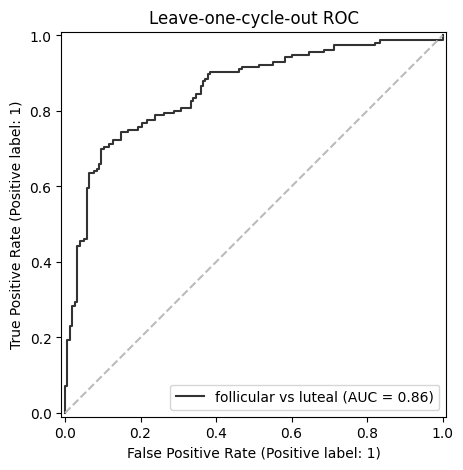

In [80]:
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

logo = LeaveOneGroupOut()

# Elastic-net logistic regression via saga (sklearn>=1.8 uses l1_ratio, not `penalty`).
# l1_ratio is tuned below: 0 = pure L2 (keeps correlated features together),
# 1 = pure L1 (sparse). saga expects the scaled features the StandardScaler provides.
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(l1_ratio=0.5, solver="saga",
                               class_weight="balanced", max_iter=20000, random_state=42)),
])

# Jointly tune regularization strength (C) and the L1/L2 mix (l1_ratio) with
# leave-one-cycle-out folds.
grid = GridSearchCV(
    pipe,
    param_grid={
        "clf__C": np.logspace(-2, 1, 12),
        "clf__l1_ratio": [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    },
    cv=logo, scoring="roc_auc", n_jobs=-1,
)
grid.fit(X, y, groups=groups)
print("Best params:", {k: round(v, 4) for k, v in grid.best_params_.items()},
      "| CV AUC:", round(grid.best_score_, 3))

# Honest out-of-fold predictions: each cycle scored by a model that never saw it.
best = grid.best_estimator_
proba_oof = cross_val_predict(best, X, y, cv=logo, groups=groups,
                              method="predict_proba", n_jobs=-1)[:, 1]
pred_oof = (proba_oof >= 0.5).astype(int)

print("\nOut-of-fold ROC AUC:", round(roc_auc_score(y, proba_oof), 3))
print(classification_report(y, pred_oof, target_names=["Follicular anchor", "Late luteal"]))
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y, pred_oof),
                   index=["follicular", "luteal"], columns=["pred_foll", "pred_lut"]))

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y, proba_oof, ax=ax, color="#333", name="follicular vs luteal")
ax.plot([0, 1], [0, 1], ls="--", color="#bbb")
ax.set_title("Leave-one-cycle-out ROC")
plt.show()

In [81]:
# Fit the final model on ALL confident rows (this is what Step 2 will apply to the full calendar).
final_model = grid.best_estimator_.fit(X, y)

coef = pd.Series(final_model.named_steps["clf"].coef_[0], index=feature_cols)
kept = coef[coef != 0].sort_values(key=np.abs, ascending=False)
print(f"L1 kept {len(kept)} / {len(feature_cols)} features. Positive = pushes toward luteal.\n")
print(kept.to_string())

L1 kept 58 / 60 features. Positive = pushes toward luteal.

hrv_rmssd_roll7                 6.549244
hrv_rmssd_roll3                -3.682635
hrv_rmssd_slope5                3.426946
resting_hr_roll7               -3.210616
hrv_rmssd_diff7                 2.925737
avg_sleep_stress_roll3          2.792706
hrv_rmssd_slope7               -2.767528
resting_hr_lag2                 2.424310
hrv_rmssd_diff3                -2.278313
avg_sleep_stress_lag2          -2.233048
resting_hr_bn                   2.211174
sleep_score_roll3               2.159266
avg_sleep_stress_lag3          -1.836293
resting_hr_diff7               -1.832928
resting_hr_lag1                 1.813928
avg_sleep_stress_slope7        -1.810729
hrv_rmssd_lag3                 -1.620263
avg_sleep_stress_diff3         -1.615169
avg_sleep_respiration_diff7     1.565901
avg_sleep_respiration_roll3     1.535524
avgStressLevel_roll3           -1.503892
avg_sleep_stress_roll7          1.358246
sleep_score_lag3               -1.3338

In [113]:
# --- Why was HRV dropped? Redundancy diagnostic ---
# A zero coefficient is NOT an importance score: L1/elastic-net keeps one representative
# per correlated cluster. Here we check HRV's *standalone* signal and its correlation with
# the features the model actually kept.

# 1) Univariate leave-one-cycle-out AUC for every feature (signal in isolation).
def univariate_auc(col):
    p = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ])
    proba = cross_val_predict(p, X[[col]], y, cv=logo, groups=groups,
                              method="predict_proba")[:, 1]
    return roc_auc_score(y, proba)

uni = pd.Series({c: univariate_auc(c) for c in feature_cols}, name="univar_auc")
base = uni.index.str.replace(r"_(bn|lag|roll|slope|diff)\d*$", "", regex=True)

# print("Best STANDALONE leave-one-cycle-out AUC per signal:")
# print(uni.groupby(base).max().sort_values(ascending=False).round(3).to_string())
#
# hrv_best = uni.filter(like="hrv_rmssd").sort_values(ascending=False)
# print(f"\nBest HRV feature on its own: {hrv_best.index[0]} = {hrv_best.iloc[0]:.3f} AUC")
# print("Univariate AUC of the features the model KEPT:")
# print(uni.loc[kept.index].round(3).to_string())
#
# # 2) Correlation of the KEPT features with the HRV features they crowded out.
# hrv_feats = [c for c in feature_cols if c.startswith("hrv_rmssd")]
# corr_tbl = X[list(kept.index) + hrv_feats].corr().loc[kept.index, hrv_feats].abs()
# print("\n|correlation| of kept features (columns) vs HRV features (rows):")
# print(corr_tbl.T.round(2).to_string())

## Step 2 — Score `P(luteal)` across the full calendar

Now apply the classifier to **every day**, including the `Not logged` middle where the
transition lives, to get a per-day `P(luteal)` trajectory (low early in the cycle, high late).

To keep it **honest**, each cycle is scored by a model trained on the *other* cycles'
anchor rows only (leave-one-cycle-out): the model never sees the cycle it scores, and never
trains on `Not logged` days. We reuse the winning hyperparameters from Step 1.

Three views:
1. **Sanity table** — mean `P(luteal)` by phase/anchor: should be low for follicular anchors, high for
   `Late luteal`, and intermediate for `Not logged` (the middle straddles the transition).
2. **Aggregate** — mean `P(luteal)` vs cycle-day (forward) and vs days-before-next-period
   (backward); we expect a rise from ~0 to ~1, sharper in the backward view.
3. **Per-cycle small multiples** — each cycle's trajectory with a phase-color strip, so we can
   eyeball where `P(luteal)` crosses 0.5 relative to the labelled anchors. Step 3 detects that
   crossing automatically.

In [86]:
from sklearn.base import clone

# Honest full-calendar scoring: predict each cycle with a model trained on the OTHER
# cycles' anchor rows only (leave-one-cycle-out). Reuses Step 1's winning hyperparameters.
scored = df_feat.copy()
scored["p_luteal"] = np.nan
model_tmpl = clone(grid.best_estimator_)   # winning C / l1_ratio, unfitted

for cid in scored["cycle_id"].unique():
    train_mask = groups != cid             # anchor rows from all other complete cycles
    if y[train_mask].nunique() < 2:
        continue
    m = clone(model_tmpl).fit(X[train_mask], y[train_mask])
    rows = scored["cycle_id"] == cid
    scored.loc[rows, "p_luteal"] = m.predict_proba(scored.loc[rows, feature_cols])[:, 1]

print("Days scored:", scored["p_luteal"].notna().sum(), "/", len(scored))
print("\nMean P(luteal) by reproductive phase (out-of-fold):")
print(scored.groupby("cycle_phase")["p_luteal"].agg(["mean", "std", "count"]).round(3)
      .reindex(["Early follicular", "Not logged", "Late luteal"]))

print("\nMean P(luteal) by period event (out-of-fold):")
print(scored.groupby("is_period")["p_luteal"].agg(["mean", "std", "count"]).round(3)
      .rename(index={False: "not period", True: "period"}))


Days scored: 731 / 731

Mean P(luteal) by reproductive phase (out-of-fold):
                   mean    std  count
cycle_phase                          
Early follicular  0.212  0.295    162
Not logged        0.547  0.401    413
Late luteal       0.741  0.359    156

Mean P(luteal) by period event (out-of-fold):
             mean    std  count
is_period                      
not period  0.582  0.404    595
period      0.218  0.297    136


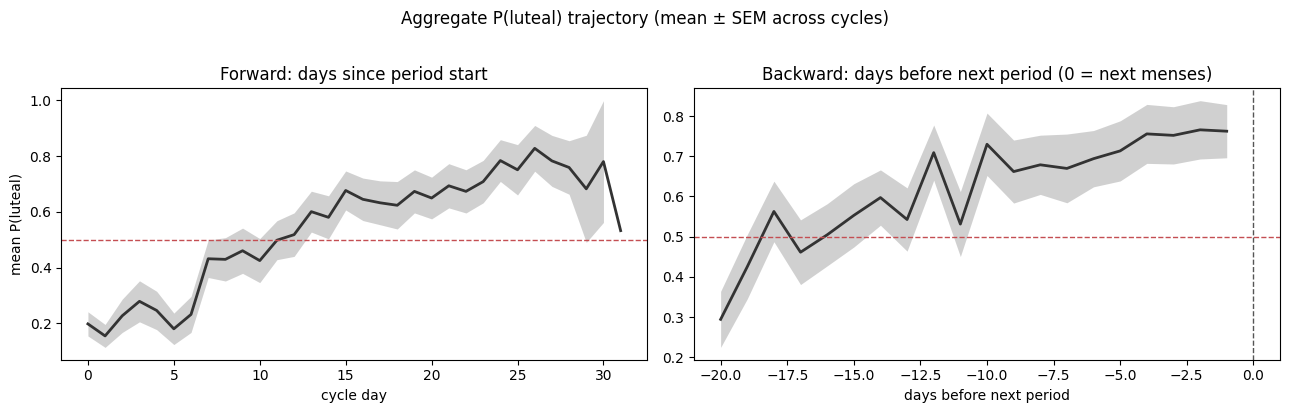

In [87]:
# Aggregate P(luteal): forward (days since period start) and backward (days before next period).
scored_complete = scored[scored["cycle_len"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

m, se, n = aligned_profile(scored_complete[scored_complete["cycle_day"].between(0, 32)],
                           "cycle_day", "p_luteal")
axes[0].plot(m.index, m.values, color="#333", lw=2)
axes[0].fill_between(m.index, m - se, m + se, color="#666", alpha=0.3, lw=0)
axes[0].axhline(0.5, color="#c44e52", ls="--", lw=1)
axes[0].set_title("Forward: days since period start")
axes[0].set_xlabel("cycle day")
axes[0].set_ylabel("mean P(luteal)")

back = scored_complete[scored_complete["rev_day"].between(-20, 0)]
m, se, n = aligned_profile(back, "rev_day", "p_luteal")
axes[1].plot(m.index, m.values, color="#333", lw=2)
axes[1].fill_between(m.index, m - se, m + se, color="#666", alpha=0.3, lw=0)
axes[1].axhline(0.5, color="#c44e52", ls="--", lw=1)
axes[1].axvline(0, color="#555", ls="--", lw=1)
axes[1].set_title("Backward: days before next period (0 = next menses)")
axes[1].set_xlabel("days before next period")

fig.suptitle("Aggregate P(luteal) trajectory (mean ± SEM across cycles)", y=1.02)
fig.tight_layout()
plt.show()

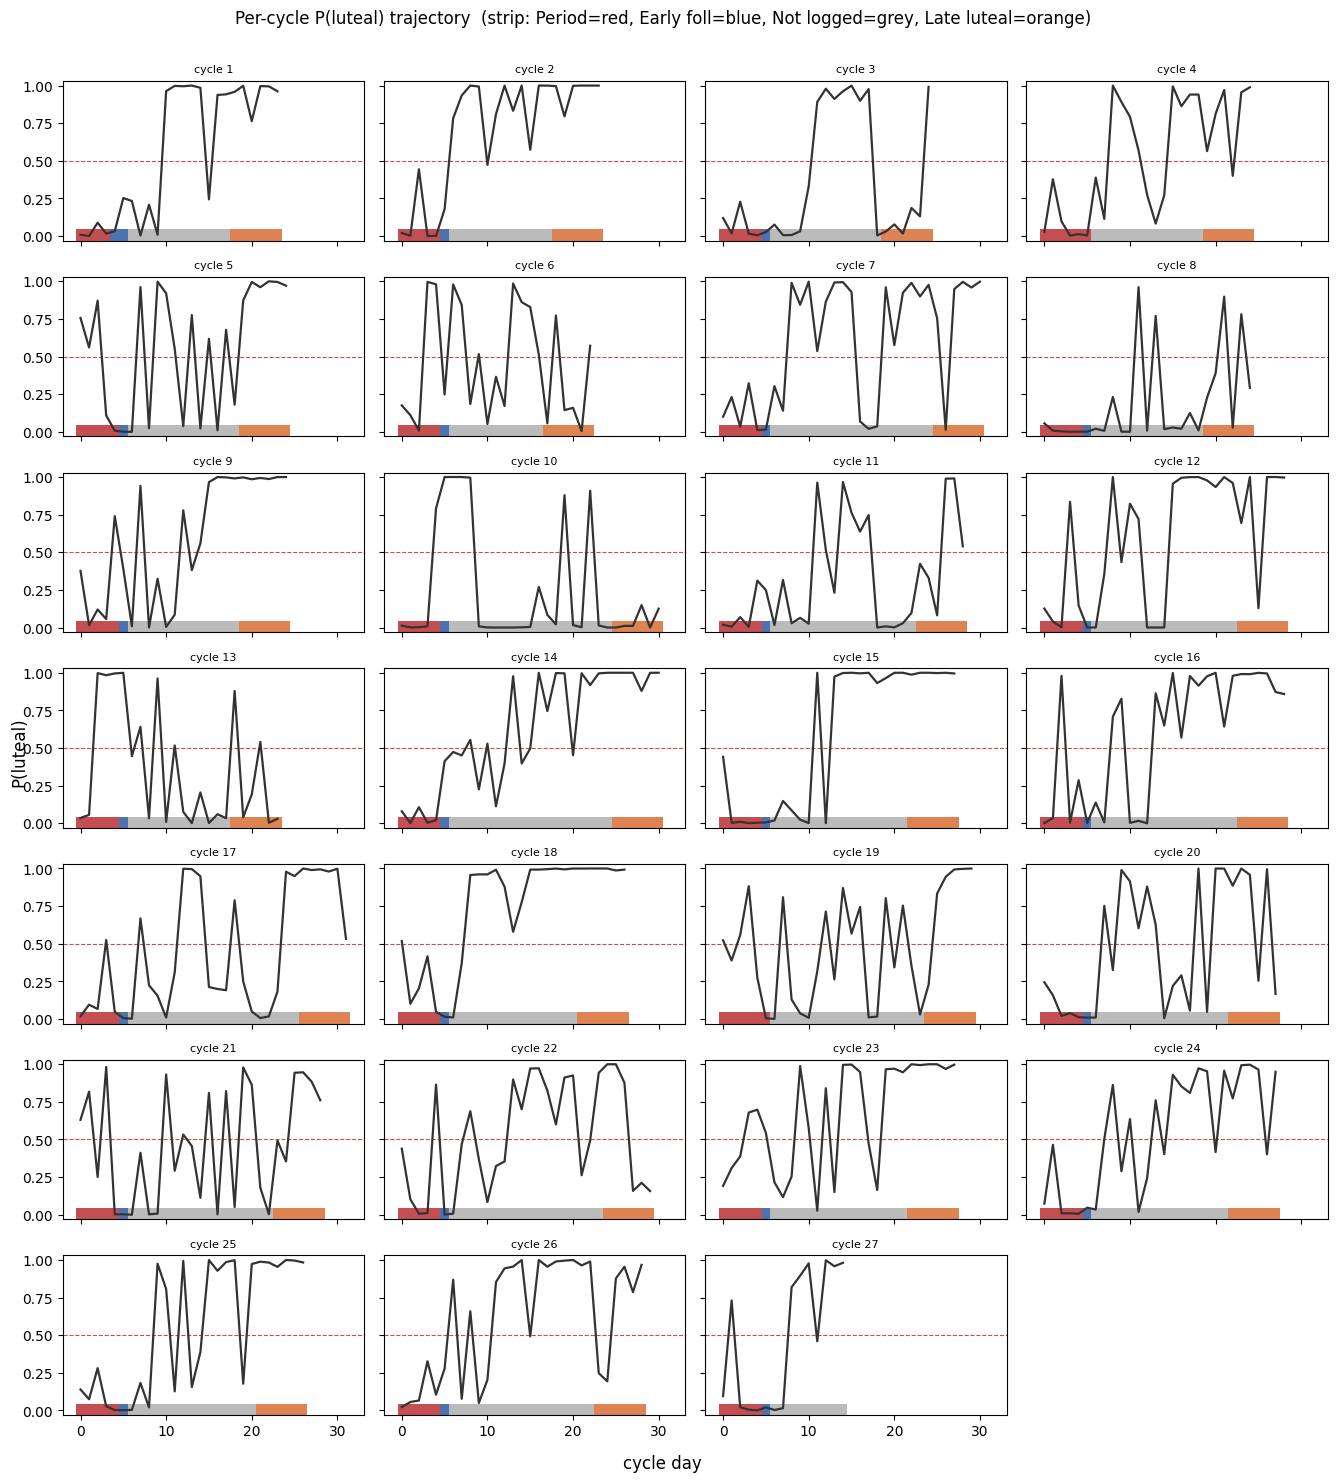

In [88]:
# Per-cycle P(luteal) trajectories. The colored strip along the bottom shows the labelled
# phase each day; the transition should sit where the black curve crosses 0.5 (red line),
# inside the grey (Not logged) band.
cyc_ids = sorted(scored["cycle_id"].unique())
ncol = 4
nrow = int(np.ceil(len(cyc_ids) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.1 * nrow),
                         sharex=True, sharey=True)

for ax, cid in zip(axes.flat, cyc_ids):
    g = scored[scored["cycle_id"] == cid].sort_values("cycle_day")
    ax.plot(g["cycle_day"], g["p_luteal"], color="#333", lw=1.6, zorder=3)
    ax.axhline(0.5, color="#c44e52", ls="--", lw=0.8, zorder=2)
    for _, r in g.iterrows():
        ax.axvspan(r["cycle_day"] - 0.5, r["cycle_day"] + 0.5, ymin=0, ymax=0.07,
                   color=PHASE_COLOR.get("Period" if r.get("is_period", False) else r["cycle_phase"], "#ccc"), lw=0, zorder=1)
    ax.set_title(f"cycle {cid}", fontsize=8)
    ax.set_ylim(-0.03, 1.03)

for ax in axes.flat[len(cyc_ids):]:
    ax.axis("off")

fig.supxlabel("cycle day")
fig.supylabel("P(luteal)")
fig.suptitle("Per-cycle P(luteal) trajectory  (strip: Period=red, Early foll=blue, "
             "Not logged=grey, Late luteal=orange)", y=1.005)
fig.tight_layout()
plt.show()

## Step 3 — Locate the transition per cycle

Use the full-calendar `P(luteal)` trajectory from Step 2 to estimate one follicular→luteal transition per complete cycle.

The transition should live in the biologically plausible middle of the cycle, not just anywhere `P(luteal)` happens to wobble upward. The search window is therefore constrained by known period timing:

- it starts after the period has ended plus a small follicular buffer,
- it cannot imply an implausibly long luteal phase,
- it must leave at least a small luteal tail before the next period,
- and it is intersected with the unlabeled `Not logged` segment.

Within that constrained window, the main estimate is a two-level change point: the split that best explains the probability trajectory as a low plateau followed by a high plateau. A 0.5 upward crossing is retained as a diagnostic/fallback, but not allowed to dominate when the whole cycle is shifted above or below 0.5.

Some cycles do not contain a usable low-to-high step in `P(luteal)`. Those get a low-confidence midpoint fallback inside the constrained window and are explicitly marked.


In [108]:
# Physiological search-window constraints. These are deliberately separate from the
# review band below: the constraints prevent impossible transition locations, while
# the review band still reports whether the final luteal length looks plausible.
MIN_DAYS_AFTER_PERIOD_END = 4
MIN_LUTEAL_DAYS = 4
MAX_LUTEAL_DAYS = 19


def first_upward_crossing(days, probs, threshold=0.5):
    """Return an interpolated cycle-day where probs first cross threshold upward."""
    days = np.asarray(days, dtype=float)
    probs = np.asarray(probs, dtype=float)

    valid = np.isfinite(days) & np.isfinite(probs)
    days = days[valid]
    probs = probs[valid]
    if len(days) == 0:
        return np.nan

    above = probs >= threshold
    if above[0]:
        return days[0]

    for i in range(1, len(days)):
        if above[i] and probs[i - 1] < threshold:
            dy = days[i] - days[i - 1]
            dp = probs[i] - probs[i - 1]
            if dp == 0:
                return days[i]
            frac = (threshold - probs[i - 1]) / dp
            return days[i - 1] + frac * dy
    return np.nan


def two_level_change_point(days, probs, min_side=2):
    """Best low-then-high step split by within-segment squared error."""
    days = np.asarray(days, dtype=float)
    probs = np.asarray(probs, dtype=float)

    valid = np.isfinite(days) & np.isfinite(probs)
    days = days[valid]
    probs = probs[valid]
    if len(days) < 2 * min_side:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    best = None
    total_sse = ((probs - probs.mean()) ** 2).sum()
    for split in range(min_side, len(probs) - min_side + 1):
        left = probs[:split]
        right = probs[split:]
        left_mean = left.mean()
        right_mean = right.mean()
        delta = right_mean - left_mean
        if delta <= 0:
            continue
        sse = ((left - left_mean) ** 2).sum() + ((right - right_mean) ** 2).sum()
        improvement = 0 if total_sse == 0 else 1 - (sse / total_sse)
        candidate = (sse, days[split], left_mean, right_mean, delta, improvement)
        if best is None or candidate[0] < best[0]:
            best = candidate

    if best is None:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    sse, split_day, left_mean, right_mean, delta, improvement = best
    return split_day, left_mean, right_mean, delta, improvement


def locate_transition_for_cycle(
    g,
    threshold=0.5,
    min_side=2,
    min_delta=0.03,
    min_days_after_period_end=MIN_DAYS_AFTER_PERIOD_END,
    min_luteal_days=MIN_LUTEAL_DAYS,
    max_luteal_days=MAX_LUTEAL_DAYS,
):
    g = g.sort_values("cycle_day").copy()
    cycle_len = g["cycle_len"].dropna()
    next_period_start = g["next_period_start"].dropna()
    period_days = g.loc[g["is_period"], "cycle_day"]

    if cycle_len.empty or next_period_start.empty or period_days.empty:
        return None

    cycle_len = int(cycle_len.iloc[0])
    next_period_start = next_period_start.iloc[0]
    period_end_day = int(period_days.max()) + 1

    constrained_start = max(
        period_end_day + min_days_after_period_end,
        cycle_len - max_luteal_days,
    )
    constrained_end = cycle_len - min_luteal_days

    candidates = g.loc[
        (g["cycle_phase"] == "Not logged")
        & g["cycle_day"].between(constrained_start, constrained_end)
        & g["p_luteal"].notna(),
        ["date", "cycle_day", "p_luteal", "cycle_phase", "garmin_predicted_fertile"],
    ].copy()

    if candidates.empty:
        return None

    candidates["p_smooth"] = candidates["p_luteal"].rolling(
        window=3,
        center=True,
        min_periods=1,
    ).mean()

    days = candidates["cycle_day"].to_numpy()
    probs = candidates["p_smooth"].to_numpy()

    crossing_day = first_upward_crossing(days, probs, threshold=threshold)
    cp_day, cp_low, cp_high, cp_delta, cp_improvement = two_level_change_point(
        days,
        probs,
        min_side=min_side,
    )

    if np.isfinite(cp_day) and cp_delta >= min_delta:
        transition_day = cp_day
        method = "change point"
        confidence = "model-supported"
    elif np.isfinite(crossing_day) and candidates["cycle_day"].min() < crossing_day < candidates["cycle_day"].max():
        transition_day = crossing_day
        method = "0.5 crossing"
        confidence = "model-supported"
    else:
        transition_day = float(np.median(days))
        method = "constrained midpoint"
        confidence = "low"

    transition_cycle_day = int(np.clip(round(transition_day), days.min(), days.max()))
    transition_row = candidates.iloc[(candidates["cycle_day"] - transition_cycle_day).abs().argmin()]
    transition_date = pd.Timestamp(transition_row["date"])
    luteal_length_days = (next_period_start - transition_date).days

    before = candidates[candidates["cycle_day"] < transition_day]["p_smooth"]
    after = candidates[candidates["cycle_day"] >= transition_day]["p_smooth"]
    garmin_fertile = candidates[candidates["garmin_predicted_fertile"].astype(bool)]

    return {
        "cycle_id": int(g["cycle_id"].iloc[0]),
        "period_start": g["date"].min().date(),
        "next_period_start": next_period_start.date(),
        "cycle_len": cycle_len,
        "period_end_cycle_day": period_end_day,
        "constraint_start_cycle_day": constrained_start,
        "constraint_end_cycle_day": constrained_end,
        "search_start_cycle_day": int(candidates["cycle_day"].min()),
        "search_end_cycle_day": int(candidates["cycle_day"].max()),
        "transition_date": transition_date.date(),
        "transition_cycle_day": transition_cycle_day,
        "transition_cycle_day_continuous": transition_day,
        "luteal_length_days": luteal_length_days,
        "method": method,
        "confidence": confidence,
        "crossing_cycle_day": crossing_day,
        "change_point_cycle_day": cp_day,
        "change_point_delta": cp_delta,
        "change_point_improvement": cp_improvement,
        "mean_p_before": before.mean(),
        "mean_p_after": after.mean(),
        "p_at_transition": float(transition_row["p_luteal"]),
        "garmin_fertile_first_day": garmin_fertile["cycle_day"].min() if not garmin_fertile.empty else np.nan,
        "garmin_fertile_last_day": garmin_fertile["cycle_day"].max() if not garmin_fertile.empty else np.nan,
    }


transition_rows = []
for cid, g in scored_complete.groupby("cycle_id"):
    row = locate_transition_for_cycle(g)
    if row is not None:
        transition_rows.append(row)

transitions = pd.DataFrame(transition_rows).sort_values("cycle_id").reset_index(drop=True)
transitions["luteal_length_flag"] = np.where(
    transitions["luteal_length_days"].between(10, 16),
    "ok",
    "review",
)
transitions["transition_minus_garmin_start"] = (
    transitions["transition_cycle_day"] - transitions["garmin_fertile_first_day"]
)

model_supported = transitions[transitions["confidence"] == "model-supported"]
summary_cols = [
    "cycle_id", "cycle_len", "transition_date", "transition_cycle_day",
    "luteal_length_days", "luteal_length_flag", "method", "confidence",
    "constraint_start_cycle_day", "constraint_end_cycle_day", "change_point_delta",
    "garmin_fertile_first_day", "garmin_fertile_last_day",
]

print(
    "Search constraints: "
    f">= {MIN_DAYS_AFTER_PERIOD_END} days after period end, "
    f"luteal length {MIN_LUTEAL_DAYS}-{MAX_LUTEAL_DAYS} days"
)
print(f"Transitions estimated: {len(transitions)} / {scored_complete['cycle_id'].nunique()} complete cycles")
print(f"Model-supported estimates: {len(model_supported)} / {len(transitions)}")
print("\nLuteal-length validation, all estimates:")
print(transitions["luteal_length_days"].describe().round(2).to_string())
print("\nLuteal-length validation, model-supported estimates only:")
print(model_supported["luteal_length_days"].describe().round(2).to_string())
print("\nFlag counts:")
print(pd.crosstab(transitions["confidence"], transitions["luteal_length_flag"]).to_string())
print("\nEstimated transitions:")
display(transitions[summary_cols])


Search constraints: >= 4 days after period end, luteal length 4-19 days
Transitions estimated: 26 / 26 complete cycles
Model-supported estimates: 22 / 26

Luteal-length validation, all estimates:
count    26.00
mean     12.73
std       2.68
min       8.00
25%      11.00
50%      13.00
75%      14.00
max      18.00

Luteal-length validation, model-supported estimates only:
count    22.00
mean     12.86
std       2.87
min       8.00
25%      11.00
50%      13.00
75%      14.00
max      18.00

Flag counts:
luteal_length_flag  ok  review
confidence                    
low                  4       0
model-supported     16       6

Estimated transitions:


,cycle_id,cycle_len,transition_date,transition_cycle_day,luteal_length_days,luteal_length_flag,method,confidence,constraint_start_cycle_day,constraint_end_cycle_day,change_point_delta,garmin_fertile_first_day,garmin_fertile_last_day
0,1,24,2024-08-03,10,14,ok,change point,model-supported,8,20,0.592087,8,13
1,2,24,2024-08-29,12,12,ok,change point,model-supported,9,20,0.139230,9,13
2,3,25,2024-09-21,11,14,ok,change point,model-supported,9,21,0.525124,9,14
3,4,25,2024-10-20,15,10,ok,change point,model-supported,10,21,0.435634,10,14
4,5,25,2024-11-13,14,11,ok,constrained midpoint,low,9,21,NaN,9,14
5,6,23,2024-12-06,12,11,ok,change point,model-supported,9,19,0.431532,9,12
6,7,31,2025-01-06,20,11,ok,change point,model-supported,12,27,0.301369,14,20
7,8,25,2025-01-28,11,14,ok,change point,model-supported,9,21,0.044011,9,14
8,9,25,2025-02-25,14,11,ok,change point,model-supported,9,21,0.575150,9,14
9,10,31,2025-03-26,18,13,ok,change point,model-supported,12,27,0.209891,14,20


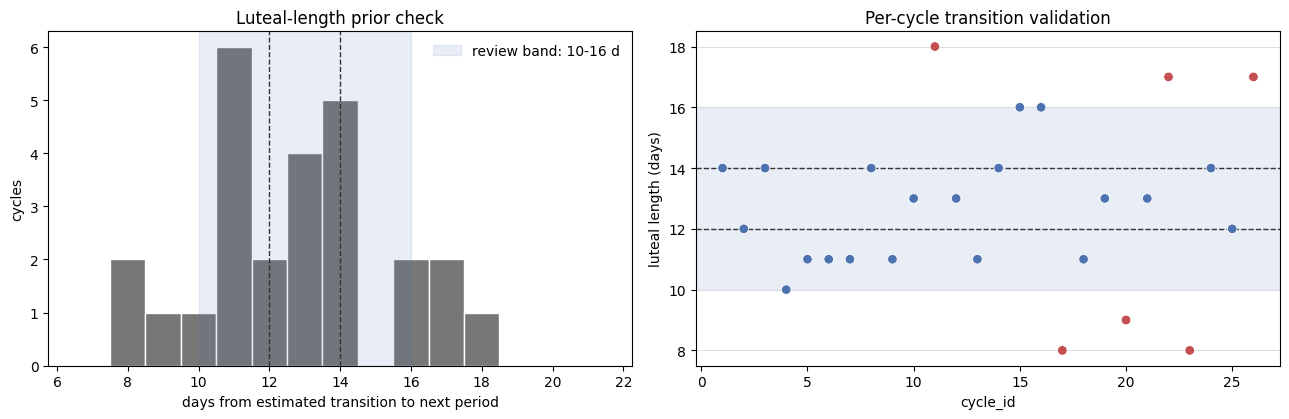

Cycles outside the 10-16 day luteal-length review band:


,cycle_id,cycle_len,transition_date,transition_cycle_day,luteal_length_days,luteal_length_flag,method,confidence,constraint_start_cycle_day,constraint_end_cycle_day,change_point_delta,garmin_fertile_first_day,garmin_fertile_last_day
10,11,29,2025-04-19,11,18,review,0.5 crossing,model-supported,10,25,NaN,12,18
16,17,32,2025-10-19,24,8,review,change point,model-supported,13,28,0.460981,15,21
19,20,28,2026-01-11,19,9,review,change point,model-supported,9,24,0.262509,11,17
21,22,30,2026-03-03,13,17,review,change point,model-supported,11,26,0.318028,13,19
22,23,28,2026-04-09,20,8,review,change point,model-supported,9,24,0.317889,11,17
25,26,29,2026-06-23,12,17,review,change point,model-supported,10,25,0.334382,12,18


In [109]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ok = transitions["luteal_length_flag"] == "ok"
colors = np.where(ok, "#4c72b0", "#c44e52")

axes[0].hist(transitions["luteal_length_days"], bins=np.arange(6.5, 21.6, 1),
             color="#777777", edgecolor="white")
axes[0].axvspan(10, 16, color="#4c72b0", alpha=0.12, label="review band: 10-16 d")
axes[0].axvline(12, color="#333333", ls="--", lw=1)
axes[0].axvline(14, color="#333333", ls="--", lw=1)
axes[0].set_xlabel("days from estimated transition to next period")
axes[0].set_ylabel("cycles")
axes[0].set_title("Luteal-length prior check")
axes[0].legend(frameon=False)

axes[1].scatter(transitions["cycle_id"], transitions["luteal_length_days"],
                c=colors, s=48, edgecolor="white", linewidth=0.6, zorder=3)
axes[1].axhspan(10, 16, color="#4c72b0", alpha=0.12)
axes[1].axhline(12, color="#333333", ls="--", lw=1)
axes[1].axhline(14, color="#333333", ls="--", lw=1)
axes[1].set_xlabel("cycle_id")
axes[1].set_ylabel("luteal length (days)")
axes[1].set_title("Per-cycle transition validation")
axes[1].grid(True, axis="y", color="#dddddd", linewidth=0.7)

fig.tight_layout()
plt.show()

review_cycles = transitions.loc[~ok, summary_cols]
if review_cycles.empty:
    print("No cycles outside the 10-16 day luteal-length review band.")
else:
    print("Cycles outside the 10-16 day luteal-length review band:")
    display(review_cycles)


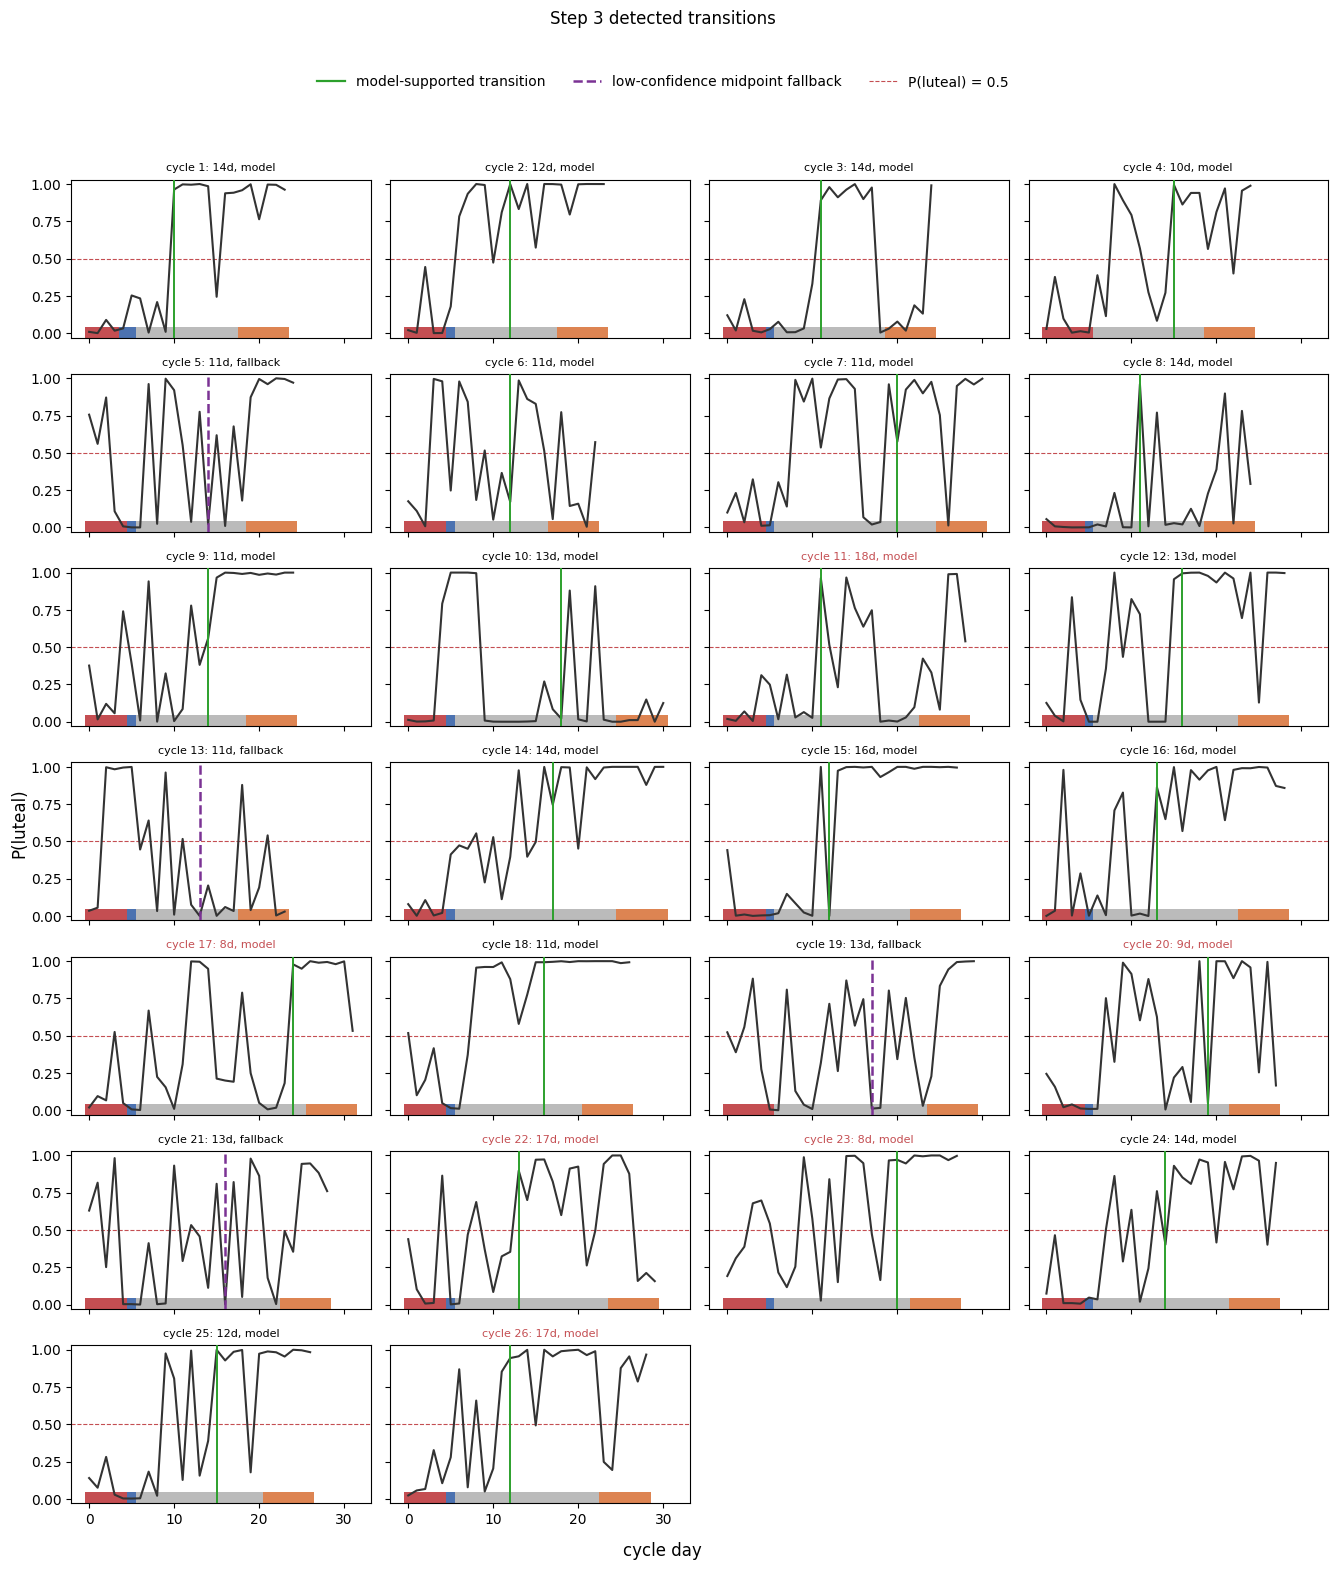

In [110]:
# Visual audit: the detected transition overlaid on each per-cycle probability curve.
# Solid green = model-supported transition. Dashed purple = low-confidence midpoint fallback.
from matplotlib.lines import Line2D

ncol = 4
nrow = int(np.ceil(len(transitions) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.15 * nrow),
                         sharex=True, sharey=True)

transition_lookup = transitions.set_index("cycle_id")
for ax, cid in zip(axes.flat, transition_lookup.index):
    g = scored_complete[scored_complete["cycle_id"] == cid].sort_values("cycle_day")
    t = transition_lookup.loc[cid]
    is_low_confidence = t["confidence"] == "low"

    transition_color = "#7b3294" if is_low_confidence else "#2ca02c"
    transition_ls = "--" if is_low_confidence else "-"
    transition_lw = 1.8 if is_low_confidence else 1.4

    ax.plot(g["cycle_day"], g["p_luteal"], color="#333333", lw=1.5, zorder=3)
    ax.axhline(0.5, color="#c44e52", ls="--", lw=0.8, zorder=2)
    ax.axvline(t["transition_cycle_day"], color=transition_color, ls=transition_ls,
               lw=transition_lw, zorder=4)

    for _, r in g.iterrows():
        ax.axvspan(r["cycle_day"] - 0.5, r["cycle_day"] + 0.5, ymin=0, ymax=0.07,
                   color=PHASE_COLOR.get("Period" if r.get("is_period", False) else r["cycle_phase"], "#ccc"), lw=0, zorder=1)

    title_color = "#c44e52" if t["luteal_length_flag"] == "review" else "black"
    confidence_label = "fallback" if is_low_confidence else "model"
    ax.set_title(f"cycle {cid}: {t['luteal_length_days']}d, {confidence_label}",
                 fontsize=8, color=title_color)
    ax.set_ylim(-0.03, 1.03)

for ax in axes.flat[len(transitions):]:
    ax.axis("off")

legend_handles = [
    Line2D([0], [0], color="#2ca02c", lw=1.6, label="model-supported transition"),
    Line2D([0], [0], color="#7b3294", lw=1.8, ls="--", label="low-confidence midpoint fallback"),
    Line2D([0], [0], color="#c44e52", lw=0.8, ls="--", label="P(luteal) = 0.5"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.005))
fig.supxlabel("cycle day")
fig.supylabel("P(luteal)")
fig.suptitle("Step 3 detected transitions", y=1.04)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## Step 4 — Direct change-point on AUC-selected engineered features

Step 3 is model-based: train a classifier on anchor labels, score every day with `P(luteal)`, then locate a transition in that probability trajectory.

Step 4 is still signal-based, but the feature choice is data-driven. First, compute standalone leave-one-cycle-out AUC for **all already-built engineered features**: raw-relative baselines, lags, rolling means, diffs, and slopes. This asks which individual feature trajectories best separate follicular-anchor days from late-luteal anchor days.

Then use the most relevant features directly: orient each selected feature so higher means "more luteal", combine them with weights proportional to `abs(AUC - 0.5)`, and apply the same two-level low→high change-point function to that composite inside the constrained middle window.

So Step 4 is not a classifier probability. It is a direct change-point on the strongest engineered biometric trajectories.


In [117]:
# --- Step 4a: standalone AUC diagnostic for all already-built engineered features ---
# This diagnostic drives Step 4: the selected features below are the ones used by the
# direct change-point detector.

def feature_family(col):
    for suffix in ("_slope", "_roll", "_diff", "_lag"):
        if suffix in col:
            return col.split(suffix)[0]
    if col.endswith("_bn"):
        return col[:-3]
    return col


def feature_kind(col):
    if "_slope" in col:
        return "slope"
    if "_roll" in col:
        return "rolling"
    if "_diff" in col:
        return "diff"
    if "_lag" in col:
        return "lag"
    if col.endswith("_bn"):
        return "baseline_norm"
    return "raw"


def standalone_feature_auc(col):
    p = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ])
    proba = cross_val_predict(
        p, X[[col]], y,
        cv=logo,
        groups=groups,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
    return roc_auc_score(y, proba)

feature_auc = pd.DataFrame({
    "feature": feature_cols,
    "auc": [standalone_feature_auc(c) for c in feature_cols],
})
feature_auc["signal"] = feature_auc["feature"].map(feature_family)
feature_auc["kind"] = feature_auc["feature"].map(feature_kind)
feature_auc["auc_distance"] = (feature_auc["auc"] - 0.5).abs()
feature_auc["direction"] = np.where(feature_auc["auc"] >= 0.5, 1.0, -1.0)
feature_auc = feature_auc.sort_values("auc_distance", ascending=False).reset_index(drop=True)

print("Top standalone engineered features by leave-one-cycle-out AUC:")
display(feature_auc.head(20).round(3))

best_by_signal = (feature_auc.sort_values("auc_distance", ascending=False)
                  .groupby("signal", as_index=False)
                  .first()
                  .sort_values("auc_distance", ascending=False))
print("Best feature per biometric signal:")
display(best_by_signal[["signal", "feature", "kind", "auc", "auc_distance"]].round(3))

# Keep a small, interpretable set. Prefer the best feature from each signal family so one
# correlated feature cluster cannot dominate the direct change-point composite.
MIN_FEATURE_AUC_DISTANCE = 0.12
MAX_STEP4_FEATURES = 4
selected_step4_features = (
    best_by_signal[best_by_signal["auc_distance"] >= MIN_FEATURE_AUC_DISTANCE]
    .head(MAX_STEP4_FEATURES)
    .copy()
)
if selected_step4_features.empty:
    selected_step4_features = best_by_signal.head(1).copy()

print("Selected Step 4 features:")
display(selected_step4_features[["signal", "feature", "kind", "auc", "direction", "auc_distance"]].round(3))


Top standalone engineered features by leave-one-cycle-out AUC:


,feature,auc,signal,kind,auc_distance,direction
0,resting_hr_bn,0.756,resting_hr,baseline_norm,0.256,1.0
1,resting_hr_roll3,0.742,resting_hr,rolling,0.242,1.0
2,avg_sleep_stress_roll3,0.739,avg_sleep_stress,rolling,0.239,1.0
3,resting_hr_lag1,0.730,resting_hr,lag,0.230,1.0
4,resting_hr_roll7,0.720,resting_hr,rolling,0.220,1.0
5,avg_sleep_stress_roll7,0.712,avg_sleep_stress,rolling,0.212,1.0
6,avg_sleep_stress_lag1,0.711,avg_sleep_stress,lag,0.211,1.0
7,avgStressLevel_roll7,0.708,avgStressLevel,rolling,0.208,1.0
8,avg_sleep_stress_bn,0.700,avg_sleep_stress,baseline_norm,0.200,1.0
9,resting_hr_lag2,0.697,resting_hr,lag,0.197,1.0


Best feature per biometric signal:


,signal,feature,kind,auc,auc_distance
4,resting_hr,resting_hr_bn,baseline_norm,0.756,0.256
2,avg_sleep_stress,avg_sleep_stress_roll3,rolling,0.739,0.239
0,avgStressLevel,avgStressLevel_roll7,rolling,0.708,0.208
3,hrv_rmssd,hrv_rmssd_diff7,diff,0.679,0.179
1,avg_sleep_respiration,avg_sleep_respiration_slope7,slope,0.645,0.145
5,sleep_score,sleep_score_lag1,lag,0.612,0.112


Selected Step 4 features:


,signal,feature,kind,auc,direction,auc_distance
4,resting_hr,resting_hr_bn,baseline_norm,0.756,1.0,0.256
2,avg_sleep_stress,avg_sleep_stress_roll3,rolling,0.739,1.0,0.239
0,avgStressLevel,avgStressLevel_roll7,rolling,0.708,1.0,0.208
3,hrv_rmssd,hrv_rmssd_diff7,diff,0.679,1.0,0.179


In [118]:
# --- Step 4b: direct two-level change point on AUC-selected engineered features ---
# Build an oriented, AUC-weighted composite from the selected engineered features.
# This is not P(luteal): no multifeature classifier is fitted here.
step4 = scored_complete.copy()
selected_records = selected_step4_features.to_dict(orient="records")
selected_cols = []
weights = {}

for rec in selected_records:
    src_col = rec["feature"]
    out_col = f"step4_{src_col}"
    direction = rec["direction"]
    centered = direction * step4[src_col]
    scale = centered.std(skipna=True)
    if not np.isfinite(scale) or scale == 0:
        continue
    step4[out_col] = (centered - centered.mean(skipna=True)) / scale
    selected_cols.append(out_col)
    weights[out_col] = rec["auc_distance"]

if not selected_cols:
    raise ValueError("No usable Step 4 features after scaling.")

weight_sum = sum(weights.values())
step4["step4_composite"] = sum(step4[c] * weights[c] for c in selected_cols) / weight_sum

print("Step 4 composite weights:")
print({c.replace("step4_", ""): round(w / weight_sum, 3) for c, w in weights.items()})


def locate_transition_feature_step(
    g,
    min_side=2,
    min_delta=0.15,
    smooth=3,
    min_days_after_period_end=MIN_DAYS_AFTER_PERIOD_END,
    min_luteal_days=MIN_LUTEAL_DAYS,
    max_luteal_days=MAX_LUTEAL_DAYS,
):
    g = g.sort_values("cycle_day").copy()
    cycle_len = g["cycle_len"].dropna()
    next_period_start = g["next_period_start"].dropna()
    period_days = g.loc[g["is_period"], "cycle_day"]
    if cycle_len.empty or next_period_start.empty or period_days.empty:
        return None

    cycle_len = int(cycle_len.iloc[0])
    next_period_start = next_period_start.iloc[0]
    period_end_day = int(period_days.max()) + 1
    constrained_start = max(period_end_day + min_days_after_period_end, cycle_len - max_luteal_days)
    constrained_end = cycle_len - min_luteal_days

    candidates = g.loc[
        (g["cycle_phase"] == "Not logged")
        & g["cycle_day"].between(constrained_start, constrained_end)
        & g["step4_composite"].notna(),
        ["date", "cycle_day", "step4_composite", "garmin_predicted_fertile"],
    ].copy()
    if len(candidates) < 2 * min_side:
        return None

    candidates["step4_smooth"] = candidates["step4_composite"].rolling(
        smooth,
        center=True,
        min_periods=1,
    ).mean()
    days = candidates["cycle_day"].to_numpy(dtype=float)
    comp = candidates["step4_smooth"].to_numpy(dtype=float)

    split_day, left_mean, right_mean, delta, improvement = two_level_change_point(
        days,
        comp,
        min_side=min_side,
    )

    if np.isfinite(split_day) and delta >= min_delta:
        transition_day = split_day
        confidence = "feature-step-supported"
        method = "AUC-selected feature change point"
    else:
        transition_day = float(np.median(days))
        confidence = "low"
        method = "constrained midpoint"

    transition_cycle_day = int(np.clip(round(transition_day), days.min(), days.max()))
    transition_row = candidates.iloc[(candidates["cycle_day"] - transition_cycle_day).abs().argmin()]
    transition_date = pd.Timestamp(transition_row["date"])
    luteal_length_days = (next_period_start - transition_date).days

    fertile = g[g["garmin_predicted_fertile"] == True]  # noqa: E712
    garmin_ov = int(fertile["cycle_day"].max()) if not fertile.empty else np.nan

    return {
        "cycle_id": int(g["cycle_id"].iloc[0]),
        "next_period_start": next_period_start.date(),
        "cycle_len": cycle_len,
        "period_end_cycle_day": period_end_day,
        "constraint_start_cycle_day": constrained_start,
        "constraint_end_cycle_day": constrained_end,
        "search_start_cycle_day": int(candidates["cycle_day"].min()),
        "search_end_cycle_day": int(candidates["cycle_day"].max()),
        "transition_date": transition_date.date(),
        "transition_cycle_day": transition_cycle_day,
        "transition_cycle_day_continuous": transition_day,
        "luteal_length_days": luteal_length_days,
        "method": method,
        "confidence": confidence,
        "step_delta": delta,
        "step_improvement": improvement,
        "mean_before": left_mean,
        "mean_after": right_mean,
        "garmin_ovulation_day": garmin_ov,
        "transition_minus_garmin_ov": transition_cycle_day - garmin_ov if np.isfinite(garmin_ov) else np.nan,
    }


rows_feature_step = [r for _, g in step4.groupby("cycle_id") if (r := locate_transition_feature_step(g)) is not None]
transitions_feature_step = pd.DataFrame(rows_feature_step).sort_values("cycle_id").reset_index(drop=True)
transitions_feature_step["luteal_length_flag"] = np.where(
    transitions_feature_step["luteal_length_days"].between(10, 16), "ok", "review")

n_supported = (transitions_feature_step["confidence"] == "feature-step-supported").sum()
print(f"Feature-step transitions: {len(transitions_feature_step)} cycles, "
      f"{n_supported} supported, {len(transitions_feature_step) - n_supported} low-confidence fallback")
print("\nLuteal length, all feature-step estimates:")
print(transitions_feature_step["luteal_length_days"].describe().round(2).to_string())
print("\nFlag counts:")
print(pd.crosstab(transitions_feature_step["confidence"], transitions_feature_step["luteal_length_flag"]).to_string())

gap = transitions_feature_step["transition_minus_garmin_ov"].dropna()
if not gap.empty:
    print(f"\nExternal check vs Garmin fertile-window end: median offset {gap.median():+.1f} d, "
          f"|offset|<=2 d in {(gap.abs() <= 2).sum()}/{len(gap)} cycles")

display(transitions_feature_step[[
    "cycle_id", "cycle_len", "transition_cycle_day", "luteal_length_days",
    "luteal_length_flag", "confidence", "step_delta", "step_improvement",
    "garmin_ovulation_day", "transition_minus_garmin_ov",
]].round(3))


Step 4 composite weights:
{'resting_hr_bn': 0.29, 'avg_sleep_stress_roll3': 0.271, 'avgStressLevel_roll7': 0.236, 'hrv_rmssd_diff7': 0.203}
Feature-step transitions: 26 cycles, 20 supported, 6 low-confidence fallback

Luteal length, all feature-step estimates:
count    26.00
mean     12.00
std       1.98
min       8.00
25%      11.00
50%      12.00
75%      13.00
max      17.00

Flag counts:
luteal_length_flag      ok  review
confidence                        
feature-step-supported  16       4
low                      6       0

External check vs Garmin fertile-window end: median offset -1.0 d, |offset|<=2 d in 19/26 cycles


,cycle_id,cycle_len,transition_cycle_day,luteal_length_days,luteal_length_flag,confidence,step_delta,step_improvement,garmin_ovulation_day,transition_minus_garmin_ov
0,1,24,11,13,ok,feature-step-supported,1.006,0.821,13,-2
1,2,24,13,11,ok,low,0.048,0.083,13,0
2,3,25,12,13,ok,feature-step-supported,0.257,0.482,14,-2
3,4,25,14,11,ok,low,0.052,0.203,14,0
4,5,25,16,9,review,feature-step-supported,0.315,0.799,14,2
5,6,23,12,11,ok,low,0.103,0.451,12,0
6,7,31,18,13,ok,low,NaN,NaN,20,-2
7,8,25,14,11,ok,low,NaN,NaN,14,0
8,9,25,13,12,ok,feature-step-supported,0.339,0.804,14,-1
9,10,31,22,9,review,feature-step-supported,0.253,0.743,20,2


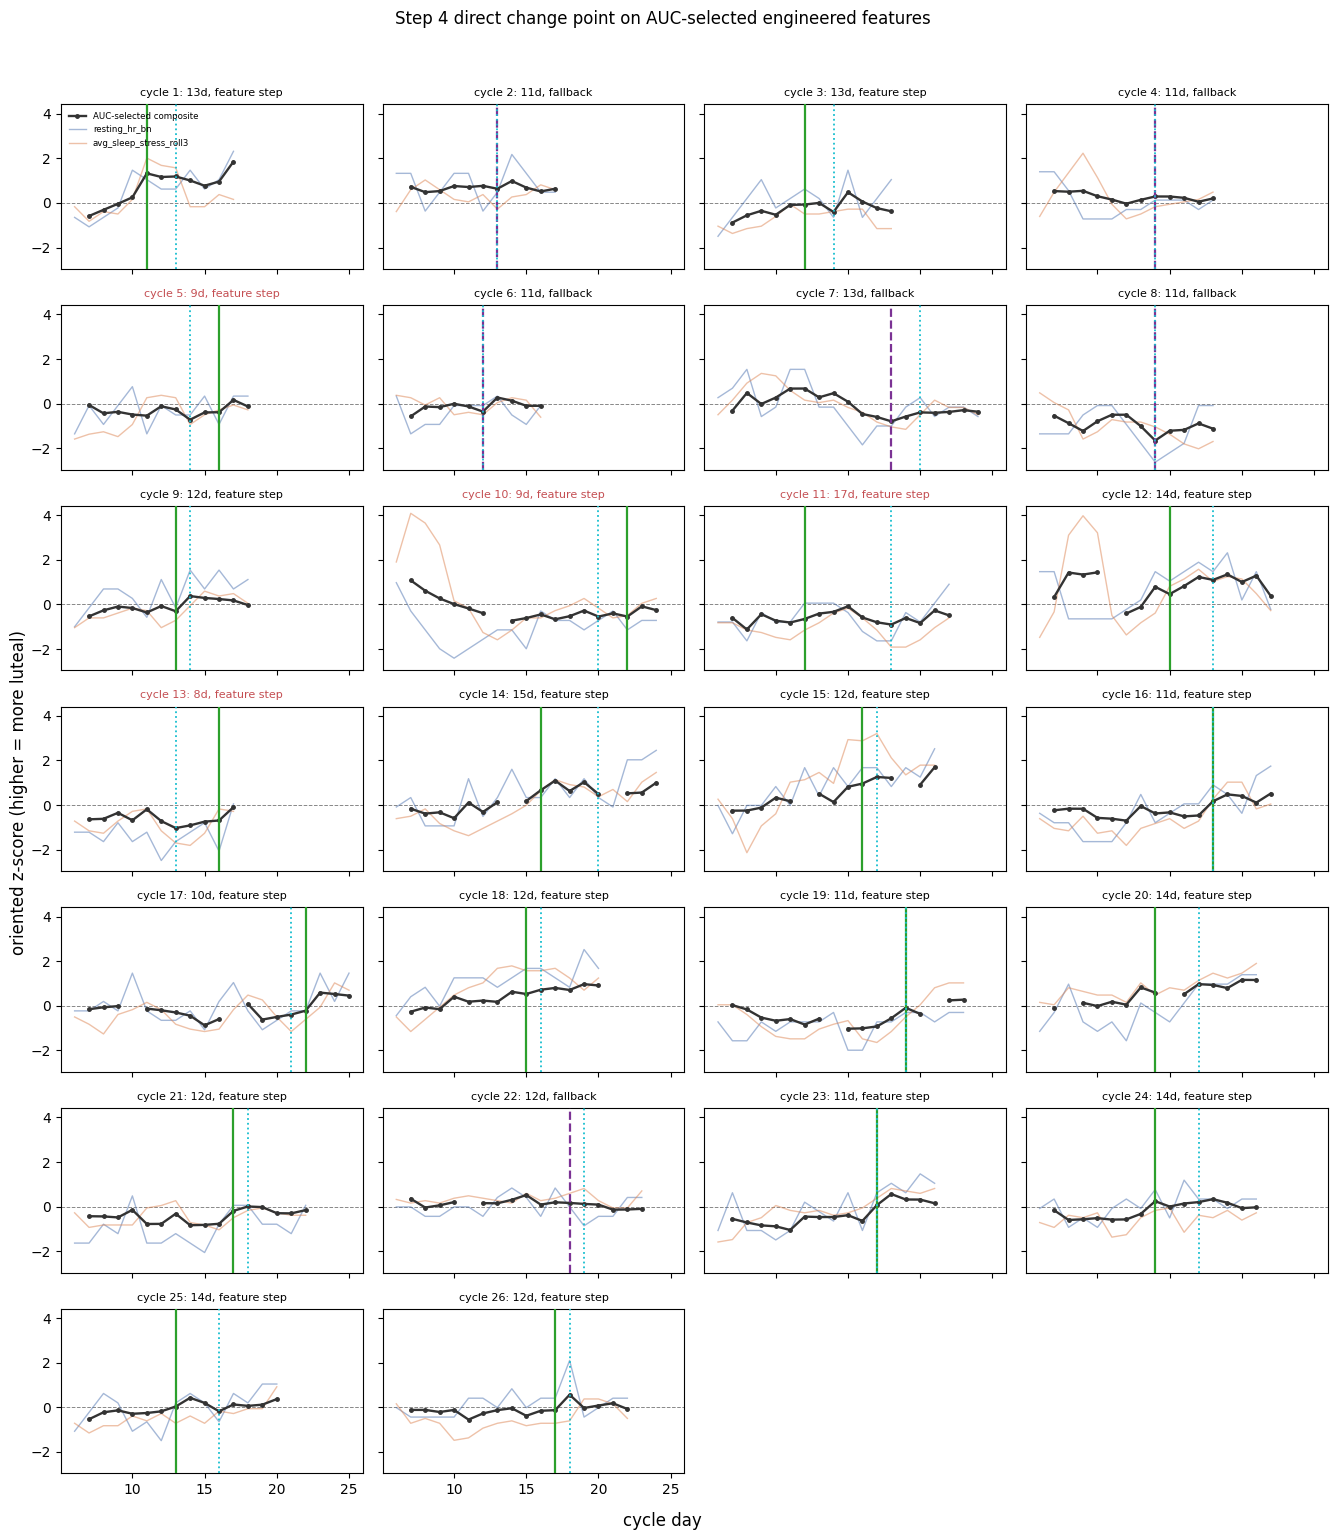

In [119]:
# Per-cycle visual audit for the AUC-selected feature composite.
feature_step_lookup = transitions_feature_step.set_index("cycle_id")
cyc_ids = [c for c in sorted(step4["cycle_id"].unique()) if c in feature_step_lookup.index]

ncol = 4
nrow = int(np.ceil(len(cyc_ids) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.15 * nrow), sharex=True, sharey=True)
fig.set_facecolor("white")

for ax, cid in zip(axes.flat, cyc_ids):
    ax.set_facecolor("white")
    g = step4[(step4["cycle_id"] == cid) & (step4["cycle_phase"] == "Not logged")].sort_values("cycle_day")
    t = feature_step_lookup.loc[cid]

    ax.plot(g["cycle_day"], g["step4_composite"], color="#333333", lw=1.7,
            marker="o", ms=2.5, label="AUC-selected composite", zorder=3)
    ax.axhline(0, color="#888", ls="--", lw=0.7, zorder=1)

    # Show the two strongest selected components for context.
    for col, color in zip(selected_cols[:2], ["#4c72b0", "#dd8452"]):
        ax.plot(g["cycle_day"], g[col], color=color, lw=1, alpha=0.5,
                label=col.replace("step4_", ""))

    tcolor = "#7b3294" if t["confidence"] == "low" else "#2ca02c"
    ax.axvline(t["transition_cycle_day"], color=tcolor,
               ls="--" if t["confidence"] == "low" else "-", lw=1.6, zorder=4)
    g_ov = t["garmin_ovulation_day"]
    if np.isfinite(g_ov):
        ax.axvline(g_ov, color="#17becf", ls=":", lw=1.3, zorder=4)

    title_color = "#c44e52" if t["luteal_length_flag"] == "review" else "black"
    label = "fallback" if t["confidence"] == "low" else "feature step"
    ax.set_title(f"cycle {cid}: {t['luteal_length_days']}d, {label}", fontsize=8, color=title_color)

for ax in axes.flat[len(cyc_ids):]:
    ax.axis("off")

axes.flat[0].legend(fontsize=6.2, frameon=False, loc="upper left")
fig.supxlabel("cycle day")
fig.supylabel("oriented z-score (higher = more luteal)")
fig.suptitle("Step 4 direct change point on AUC-selected engineered features", y=1.02)
fig.tight_layout()
plt.show()


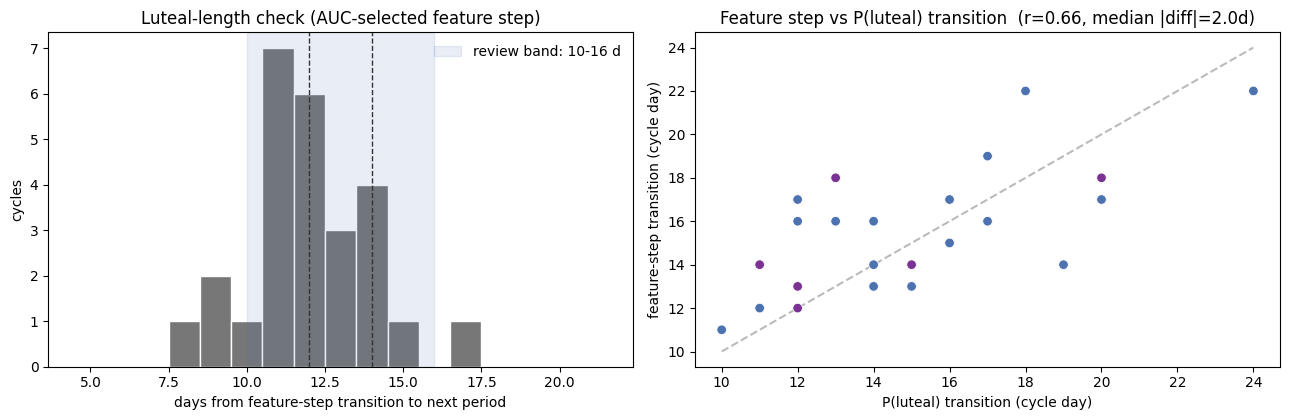

In [120]:
# Cross-check: feature-step luteal-length validation, and feature-step day vs P(luteal) day.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
fig.set_facecolor("white")

axes[0].hist(transitions_feature_step["luteal_length_days"], bins=np.arange(4.5, 21.6, 1),
             color="#777777", edgecolor="white")
axes[0].axvspan(10, 16, color="#4c72b0", alpha=0.12, label="review band: 10-16 d")
axes[0].axvline(12, color="#333", ls="--", lw=1)
axes[0].axvline(14, color="#333", ls="--", lw=1)
axes[0].set_xlabel("days from feature-step transition to next period")
axes[0].set_ylabel("cycles")
axes[0].set_title("Luteal-length check (AUC-selected feature step)")
axes[0].legend(frameon=False)

try:
    merged = transitions_feature_step.merge(
        transitions[["cycle_id", "transition_cycle_day"]],
        on="cycle_id", suffixes=("_feature", "_pluteal"))
    axes[1].scatter(merged["transition_cycle_day_pluteal"], merged["transition_cycle_day_feature"],
                    c=np.where(merged["confidence"] == "low", "#7b3294", "#4c72b0"),
                    s=48, edgecolor="white", linewidth=0.6, zorder=3)
    lo = min(merged["transition_cycle_day_pluteal"].min(), merged["transition_cycle_day_feature"].min())
    hi = max(merged["transition_cycle_day_pluteal"].max(), merged["transition_cycle_day_feature"].max())
    axes[1].plot([lo, hi], [lo, hi], ls="--", color="#bbb")
    r = merged["transition_cycle_day_feature"].corr(merged["transition_cycle_day_pluteal"])
    mad = (merged["transition_cycle_day_feature"] - merged["transition_cycle_day_pluteal"]).abs().median()
    axes[1].set_title(f"Feature step vs P(luteal) transition  (r={r:.2f}, median |diff|={mad:.1f}d)")
    axes[1].set_xlabel("P(luteal) transition (cycle day)")
    axes[1].set_ylabel("feature-step transition (cycle day)")
except (NameError, KeyError):
    axes[1].text(0.5, 0.5, "Step 3 `transitions` not available", ha="center", va="center")
    axes[1].axis("off")

fig.tight_layout()
plt.show()


## Step A — Diagnostics: is the supervised signal real, and is it really one feature?

Before choosing a modelling direction, two cheap checks:

1. **Within-cycle separation.** The pooled `P(luteal)` means look compressed (Early
   follicular-anchor ~0.42 vs Late luteal ~0.58), but a change point only needs `P(luteal)` to
   rise *inside each cycle*. Per cycle we measure `mean P(luteal) over Late luteal −
   mean over follicular anchors` and the Spearman correlation of `P(luteal)` with cycle day.
   If most cycles show a clear positive rise, the supervised signal is real but mushy in
   absolute terms; if not, the supervised route is genuinely weak and we should lean on the
   biometric change point / a duration-prior model instead.

2. **Feature stability.** A single non-zero L1 coefficient is not "only one useful feature" —
   elastic-net keeps one representative per correlated cluster. We refit the winning pipeline
   on every leave-one-cycle-out fold and record how often each feature survives and how many
   features survive per fold. A different lone feature each fold = redundancy (use ridge / a
   tree); the same feature every fold = a genuinely dominant signal.

Pooled separation (Late luteal - follicular anchor): 0.526
Per-cycle within-separation:  median 0.621, mean 0.526
Cycles with POSITIVE within-separation: 23 / 26
Per-cycle Spearman(cycle_day, P(luteal)): median 0.592, positive in 23 / 26 cycles

Folds: 26 | nonzero features per fold: median 57 (min 55, max 59)
Features selected in >=50% of folds:
                              select_freq  mean_abs_coef
hrv_rmssd_roll7                     1.000          6.043
hrv_rmssd_roll3                     1.000          3.817
resting_hr_roll7                    1.000          3.324
hrv_rmssd_slope5                    1.000          3.042
hrv_rmssd_diff7                     1.000          2.633
hrv_rmssd_slope7                    1.000          2.557
sleep_score_roll3                   1.000          2.477
resting_hr_lag2                     1.000          2.448
resting_hr_bn                       1.000          2.161
hrv_rmssd_diff3                     1.000          2.005
resting_hr_diff7        

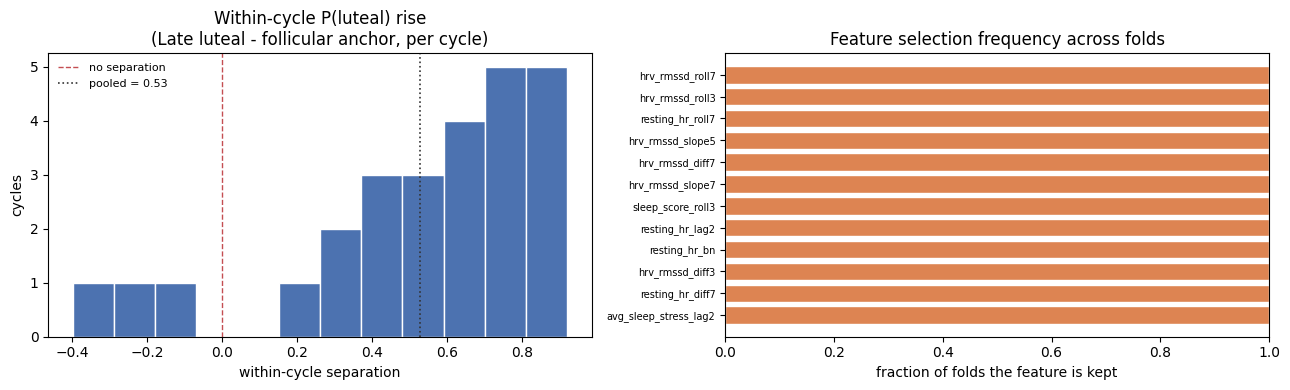

In [121]:
# ---- Step A diagnostics ----
from sklearn.base import clone

# 1) Within-cycle P(luteal) rise (does it separate follicular from luteal *per cycle*?)
rows = []
for cid, g in scored_complete.groupby("cycle_id"):
    foll = g.loc[g["is_follicular_anchor"], "p_luteal"]
    lut = g.loc[g["cycle_phase"] == "Late luteal", "p_luteal"]
    gg = g.dropna(subset=["p_luteal", "cycle_day"])
    spearman = gg["cycle_day"].corr(gg["p_luteal"], method="spearman") if len(gg) > 3 else np.nan
    rows.append({"cycle_id": cid, "p_foll": foll.mean(), "p_lut": lut.mean(),
                 "within_sep": lut.mean() - foll.mean(), "spearman_day_vs_p": spearman})
wc = pd.DataFrame(rows)

pooled_sep = (scored_complete.loc[scored_complete["cycle_phase"] == "Late luteal", "p_luteal"].mean()
              - scored_complete.loc[scored_complete["is_follicular_anchor"], "p_luteal"].mean())
print(f"Pooled separation (Late luteal - follicular anchor): {pooled_sep:.3f}")
print(f"Per-cycle within-separation:  median {wc['within_sep'].median():.3f}, "
      f"mean {wc['within_sep'].mean():.3f}")
print(f"Cycles with POSITIVE within-separation: "
      f"{int((wc['within_sep'] > 0).sum())} / {int(wc['within_sep'].notna().sum())}")
print(f"Per-cycle Spearman(cycle_day, P(luteal)): median {wc['spearman_day_vs_p'].median():.3f}, "
      f"positive in {int((wc['spearman_day_vs_p'] > 0).sum())} / "
      f"{int(wc['spearman_day_vs_p'].notna().sum())} cycles")

# 2) Feature stability across leave-one-cycle-out folds
sel = pd.DataFrame({"times_selected": 0.0, "sum_abs_coef": 0.0}, index=feature_cols)
n_nonzero = []
for tr, _ in logo.split(X, y, groups):
    m = clone(grid.best_estimator_).fit(X.iloc[tr], y.iloc[tr])
    coef = m.named_steps["clf"].coef_[0]
    nz = coef != 0
    n_nonzero.append(int(nz.sum()))
    sel.loc[np.array(feature_cols)[nz], "times_selected"] += 1
    sel["sum_abs_coef"] += np.abs(coef)
n_folds = len(n_nonzero)
sel["select_freq"] = sel["times_selected"] / n_folds
sel["mean_abs_coef"] = sel["sum_abs_coef"] / n_folds
sel = sel.sort_values(["select_freq", "mean_abs_coef"], ascending=False)

print(f"\nFolds: {n_folds} | nonzero features per fold: median {int(np.median(n_nonzero))} "
      f"(min {min(n_nonzero)}, max {max(n_nonzero)})")
print("Features selected in >=50% of folds:")
print(sel.loc[sel["select_freq"] >= 0.5, ["select_freq", "mean_abs_coef"]].round(3).to_string())

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.set_facecolor("white")
for ax in axes:
    ax.set_facecolor("white")

axes[0].hist(wc["within_sep"].dropna(), bins=12, color="#4c72b0", edgecolor="white")
axes[0].axvline(0, color="#c44e52", ls="--", lw=1, label="no separation")
axes[0].axvline(pooled_sep, color="#333", ls=":", lw=1.2, label=f"pooled = {pooled_sep:.2f}")
axes[0].set_title("Within-cycle P(luteal) rise\n(Late luteal - follicular anchor, per cycle)")
axes[0].set_xlabel("within-cycle separation"); axes[0].set_ylabel("cycles")
axes[0].legend(frameon=False, fontsize=8)

top = sel[sel["select_freq"] > 0].head(12).iloc[::-1]
axes[1].barh(top.index, top["select_freq"], color="#dd8452", edgecolor="white")
axes[1].set_xlim(0, 1)
axes[1].set_title("Feature selection frequency across folds")
axes[1].set_xlabel("fraction of folds the feature is kept")
axes[1].tick_params(axis="y", labelsize=7)

fig.tight_layout(); plt.show()